In [1]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import readsav
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

## Extract data

In [2]:
# load files
path_data = '../data/sim_series/'
N_files = 19  # 19 temporal series, need to check file N°20
data_spectra = []
data_rv = []
for i in range(1, N_files+1):
    data_spectra.append(fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie{i}.fits'))
    data_rv.append(readsav(path_data + f'res_rv_bis_6173_lionel_tau1_scaling1_sansrot_serie{i}.sav'))
data_spectra = np.array(data_spectra)
data_rv = np.array(data_rv)
data_rv[0].keys()

dict_keys(['rv_gauss', 'rv_correl', 'rv_deriv', 'xbiss', 'ybiss', 'l_true', 'lambd', 'flux_moy'])

data_spectra[ i ]: matrix with 3686 spectra of 122 elements each \
data_rv[ i ]: dictionary

In [3]:
c = 3e8  # m/s
# extract data
wl = np.array(data_rv[0]['lambd'])  # same wavelength grid for all time series (verified)
times = np.arange(0, len(data_spectra[0]) * 144, 144) / 60 / 24  # time in days, same for all time series
rv_ccf = []
template = []
for i in range(N_files):
    rv_ccf.append(data_rv[i]['rv_correl'])
    template.append(data_rv[i]['flux_moy'])
wl = np.array(wl)
rv_ccf = np.array(rv_ccf)
template = np.array(template)

## Calculate RV by template matching

In [4]:
# template matching: calculate the mean spectrum
mean_spec = np.array([np.mean(i, axis=0) for i in data_spectra])  # list of 19 mean spectra
d_S0 = np.array([np.gradient(i, wl) for i in mean_spec])  # derivative of the mean spectra

In [5]:
# calculate radial velocity by template matching
C_0 = 1000
rv_tm = []
for j in range(N_files):  # iterate over each time series
    rv_j = []
    for k in range(len(times)):  # for each spectrum
        rv_j.append(t.calculate_rv(wl, mean_spec[j], data_spectra[j][k], C_0))
    rv_tm.append(np.array(rv_j))
rv_tm = np.array(rv_tm)

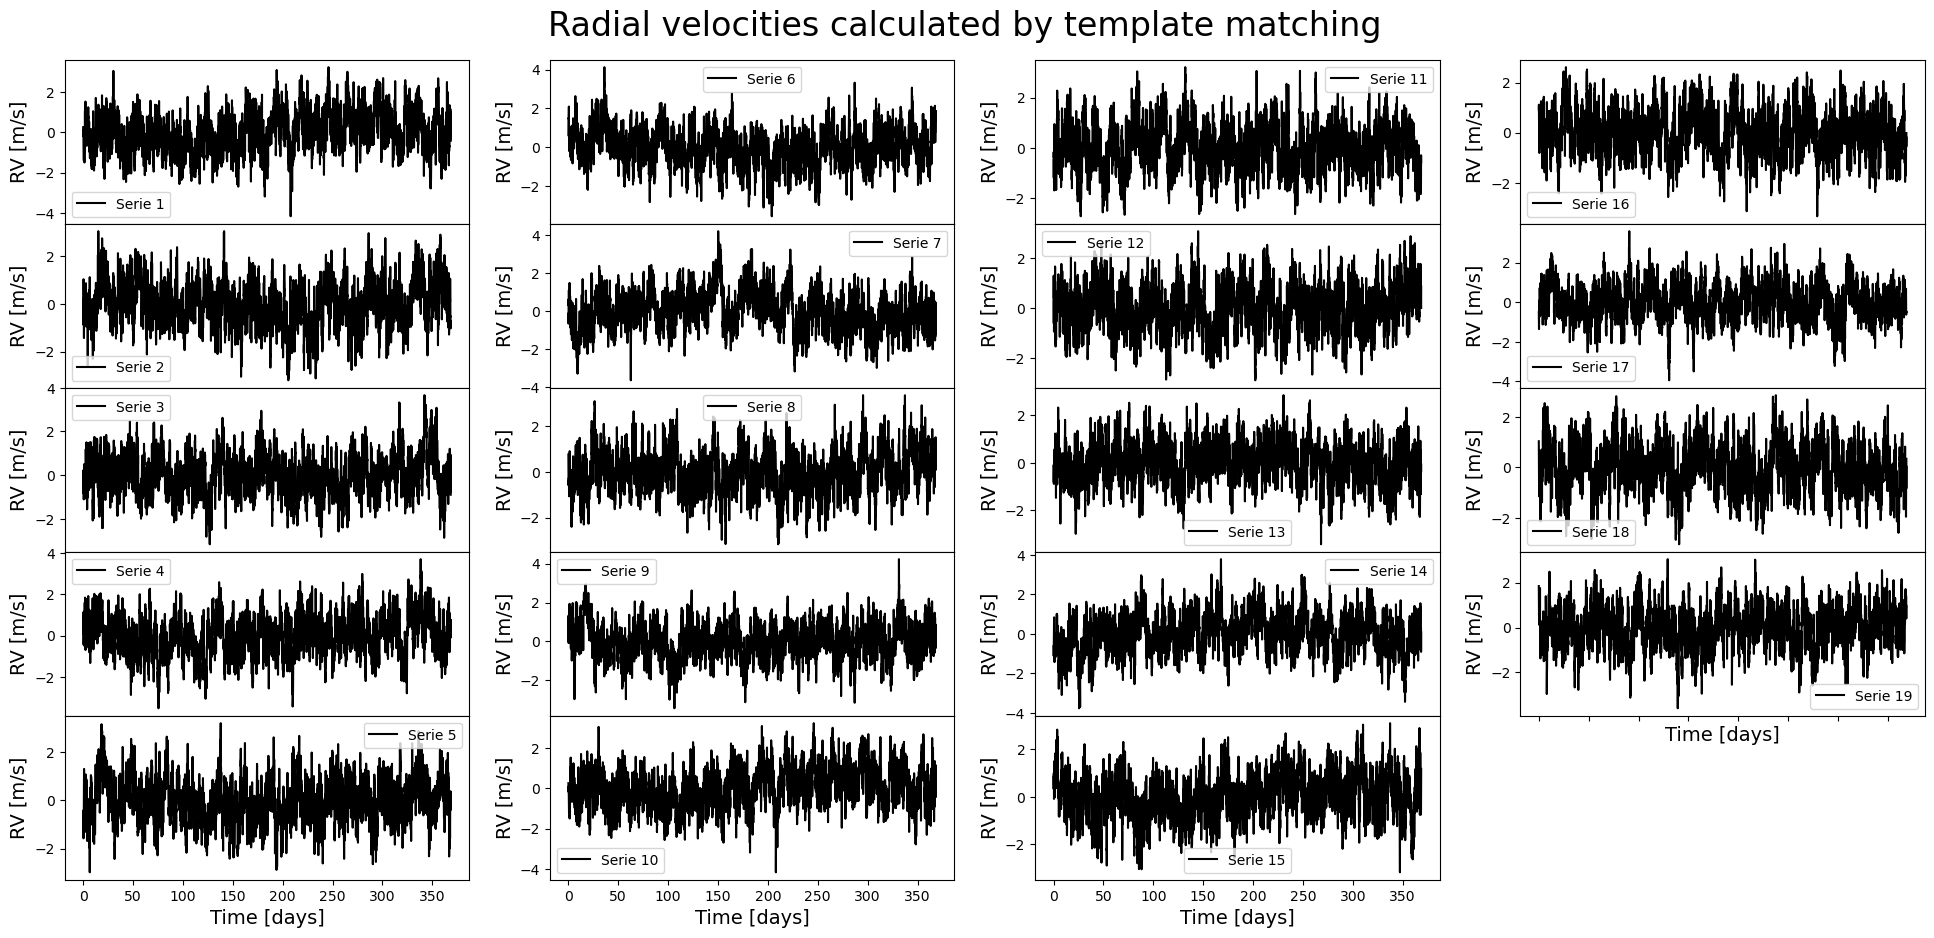

In [49]:
# plot RV
rows = 5
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(24, 10), sharex=True)
fig.suptitle('Radial velocities calculated by template matching', size=24)

r = 0
c = -1
for i in range(N_files):  # iterate over the 19 time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        c += 1  # advance to the next column
        r = 0  # reset row
    if (i + 1) % rows == 0:  # set label only in the last row of each column
        axs[r][c].set_xlabel('Time [days]', size=14)
    axs[r][c].plot(times, rv_tm[i], color='k', label=f'Serie {i+1}')
    axs[r][c].set_ylabel('RV [m/s]', size=14)
    axs[r][c].legend()
    r += 1  # advance to the next row

fig.delaxes(axs[-1][-1])  # take out extra subplot
axs[-2][-1].set_xlabel('Time [days]', size=14)

#xticks = axs[-1][-2].get_xticks()[1:]
#axs[-2][-1].set_xticks(xticks)
#axs[-2][-1].set_xticklabels([str(int(i)) for i in xticks])

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

## Calculate RV by CCF

In [6]:
delta_vel = np.linspace(-5, 5, 201)  # define RV grid
lambda_vr = np.array([wl * np.sqrt((1 - v / c) / (1 + v / c)) for v in delta_vel])  # wavelength grid for each v

In [7]:
# interpolate flux over lambda_vr to fit the originl wavelength grid (wl)
shifted_mask = []  # each element is a list of shifted masks, corresponding to each delta_vel
for i in range(N_files):
    sm_i = []  # shifted mask corresponding to the time series i
    for wl_grid in lambda_vr:  # iterate over wavelength grids
        sm_i.append(np.interp(wl, wl_grid, mean_spec[i]))
    shifted_mask.append(np.array(sm_i))
shifted_mask = np.array(shifted_mask)

In [9]:
# calculate CCF between each measured spectrum and the reference spectrum
ccf = []
for k in tqdm(range(N_files)):  # iterate over each time series
    ccf_i = []
    for j in range(len(times)):  # iterate over measured (simulated) spectra
        ccf_i.append(np.array([sum(data_spectra[k][j] * shifted_mask[k][i] / (np.linalg.norm(data_spectra[k][j]) * np.linalg.norm(shifted_mask[k][i]))) for i in range(len(delta_vel))]))  # CCF
    ccf.append(np.array(ccf_i))
ccf = np.array(ccf)

100%|██████████| 19/19 [04:20<00:00, 13.69s/it]


In [13]:
# CONTINUE FROM HERE
# fit a gaussian to each CCF
params = []
models = []
for i in tqdm(range(N_files)):  # each i is the index of a list of CCFs
    ccf_i = ccf[i]
    params_i = []
    model_i  = []
    for j in range(len(ccf_i)):  # iterate over the indices of the CCFs (each iteration is a CCF)
        params_j, _ = curve_fit(t.gaussian, delta_vel, ccf_i[j], p0=[max(ccf_i[j])- min(ccf_i[j]), 0, np.std(delta_vel), np.max(ccf_i[j])])  # fit a gaussian to the CCF and save the parameters
        model_j = t.gaussian(delta_vel, params_j[0], params_j[1], params_j[2], params_j[3])  # calculate the model using the obtained parameters
        params_i.append(params_j)  # save parameters
        model_i.append(model_j)  # save models
    params.append(params_i)  # save parameters
    models.append(model_i)  # save models
params = np.array(params)
models = np.array(models)
mean_vels = np.array([i[:, 1] for i in params])  # recover the position of the peak of each gaussian

  0%|          | 0/19 [00:00<?, ?it/s]/tmp/ipykernel_916377/357821907.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  params_j, _ = curve_fit(t.gaussian, delta_vel, ccf_i[j], p0=[max(ccf_i[j])- min(ccf_i[j]), 0, np.std(delta_vel), np.max(ccf_i[j])])  # fit a gaussian to the CCF and save the parameters
100%|██████████| 19/19 [02:49<00:00,  8.94s/it]


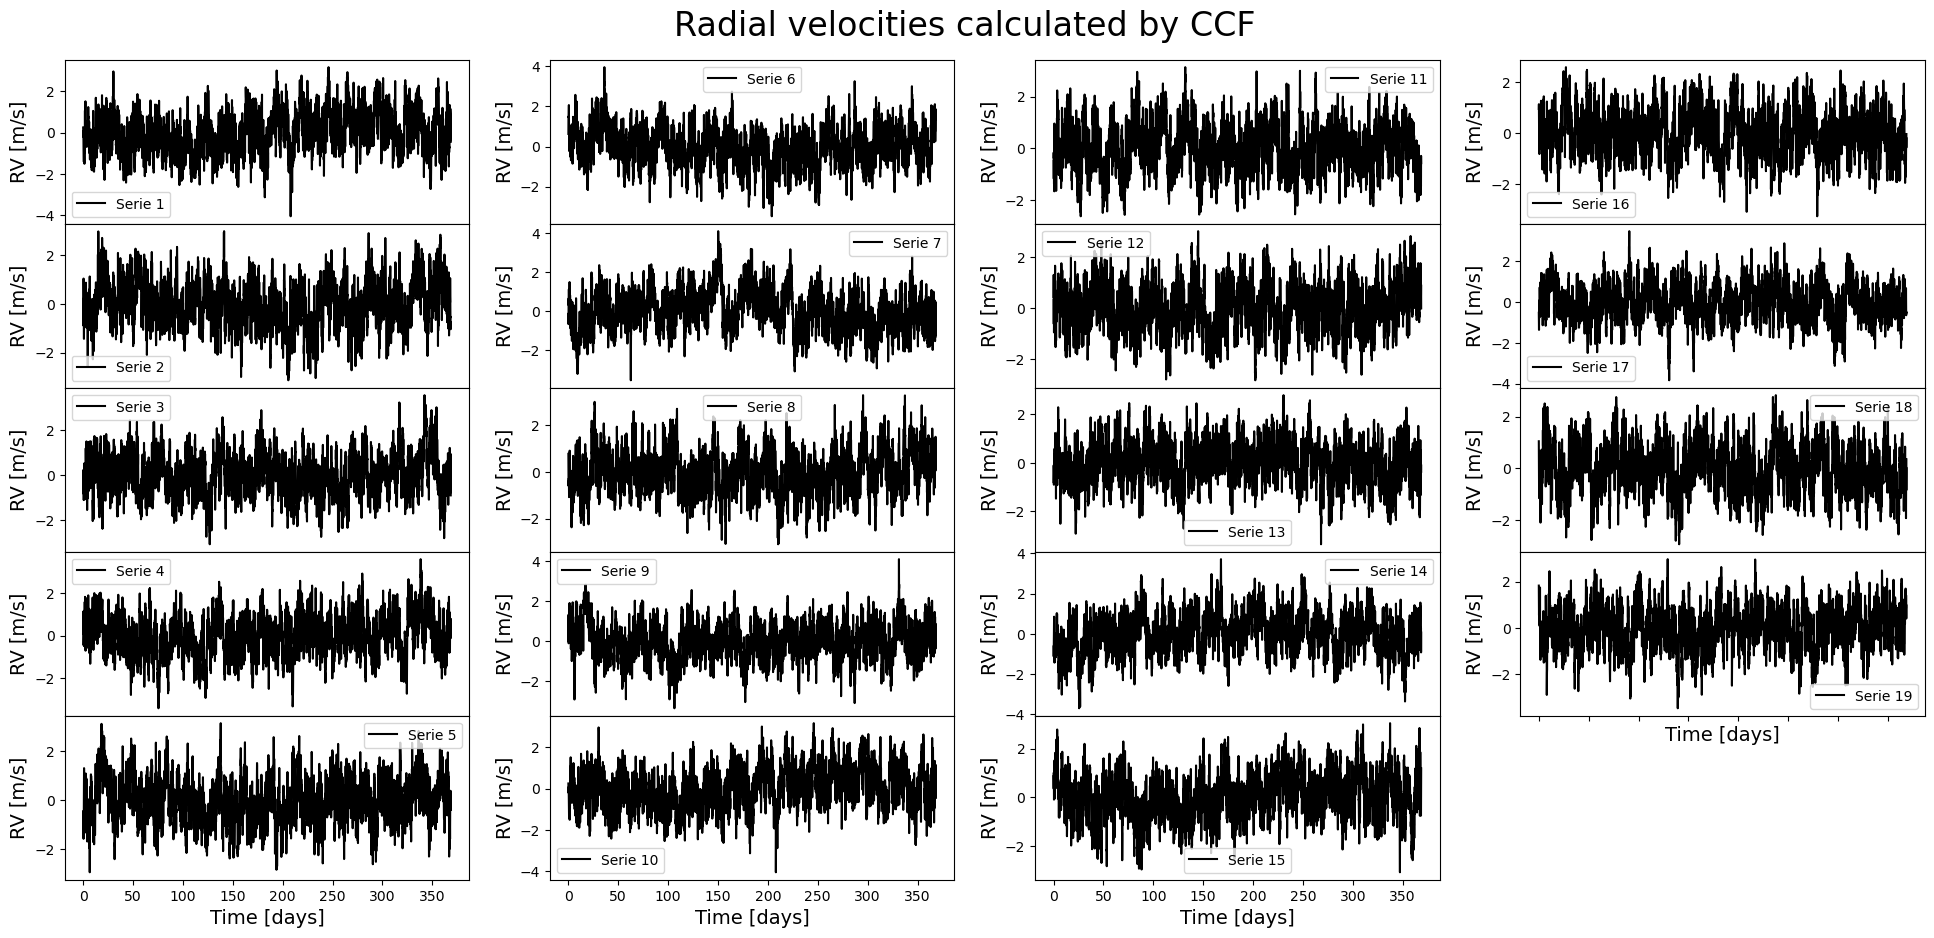

In [50]:
# plot RV
rows = 5
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(24, 10), sharex=True)
fig.suptitle('Radial velocities calculated by CCF', size=24)

r = 0
c = -1
for i in range(N_files):  # iterate over the 19 time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        c += 1  # advance to the next column
        r = 0  # reset row
    if (i + 1) % rows == 0:  # set label only in the last row of each column
        axs[r][c].set_xlabel('Time [days]', size=14)
    axs[r][c].plot(times, mean_vels[i], color='k', label=f'Serie {i+1}')
    axs[r][c].set_ylabel('RV [m/s]', size=14)
    axs[r][c].legend()
    r += 1  # advance to the next row

fig.delaxes(axs[-1][-1])  # take out extra subplot
axs[-2][-1].set_xlabel('Time [days]', size=14)

#xticks = axs[-1][-2].get_xticks()[1:]
#axs[-2][-1].set_xticks(xticks)
#axs[-2][-1].set_xticklabels([str(int(i)) for i in xticks])

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

In [51]:
rv_ccfE = mean_vels

## RV Periodograms

In [52]:
# calculate RV periodograms
dt = times[1] - times[0]  # delta time in days
dt_sec = dt * 86400  # delta time in seconds

# power spectrum
ffts = []  # FT of each temporal series
power_specs = []  # PS of each temporal serie

for i in range(N_files):
    #sp_ccf = np.fft.fft(rv_ccf[i])  # of RV calculated by CCF (Nadège)
    #power_ccf = np.abs(sp_ccf)**2

    #sp_tm = np.fft.fft(rv_tm[i])  # of RV calculated by TM
    #power_tm = np.abs(sp_tm)**2

    sp_ccfE = np.fft.fft(rv_ccfE[i])  # of RV calculated by CCF (Etienne)
    ffts.append(sp_ccfE)
    power_specs.append(np.abs(sp_ccfE)**2)

# calculate frequencies
freq_days = np.fft.fftfreq(len(times), dt)  # frequency in days^-1 same for all power spectra
freq_hz   = freq_days / 86400  # frequency in Hz
mask = freq_days > 0

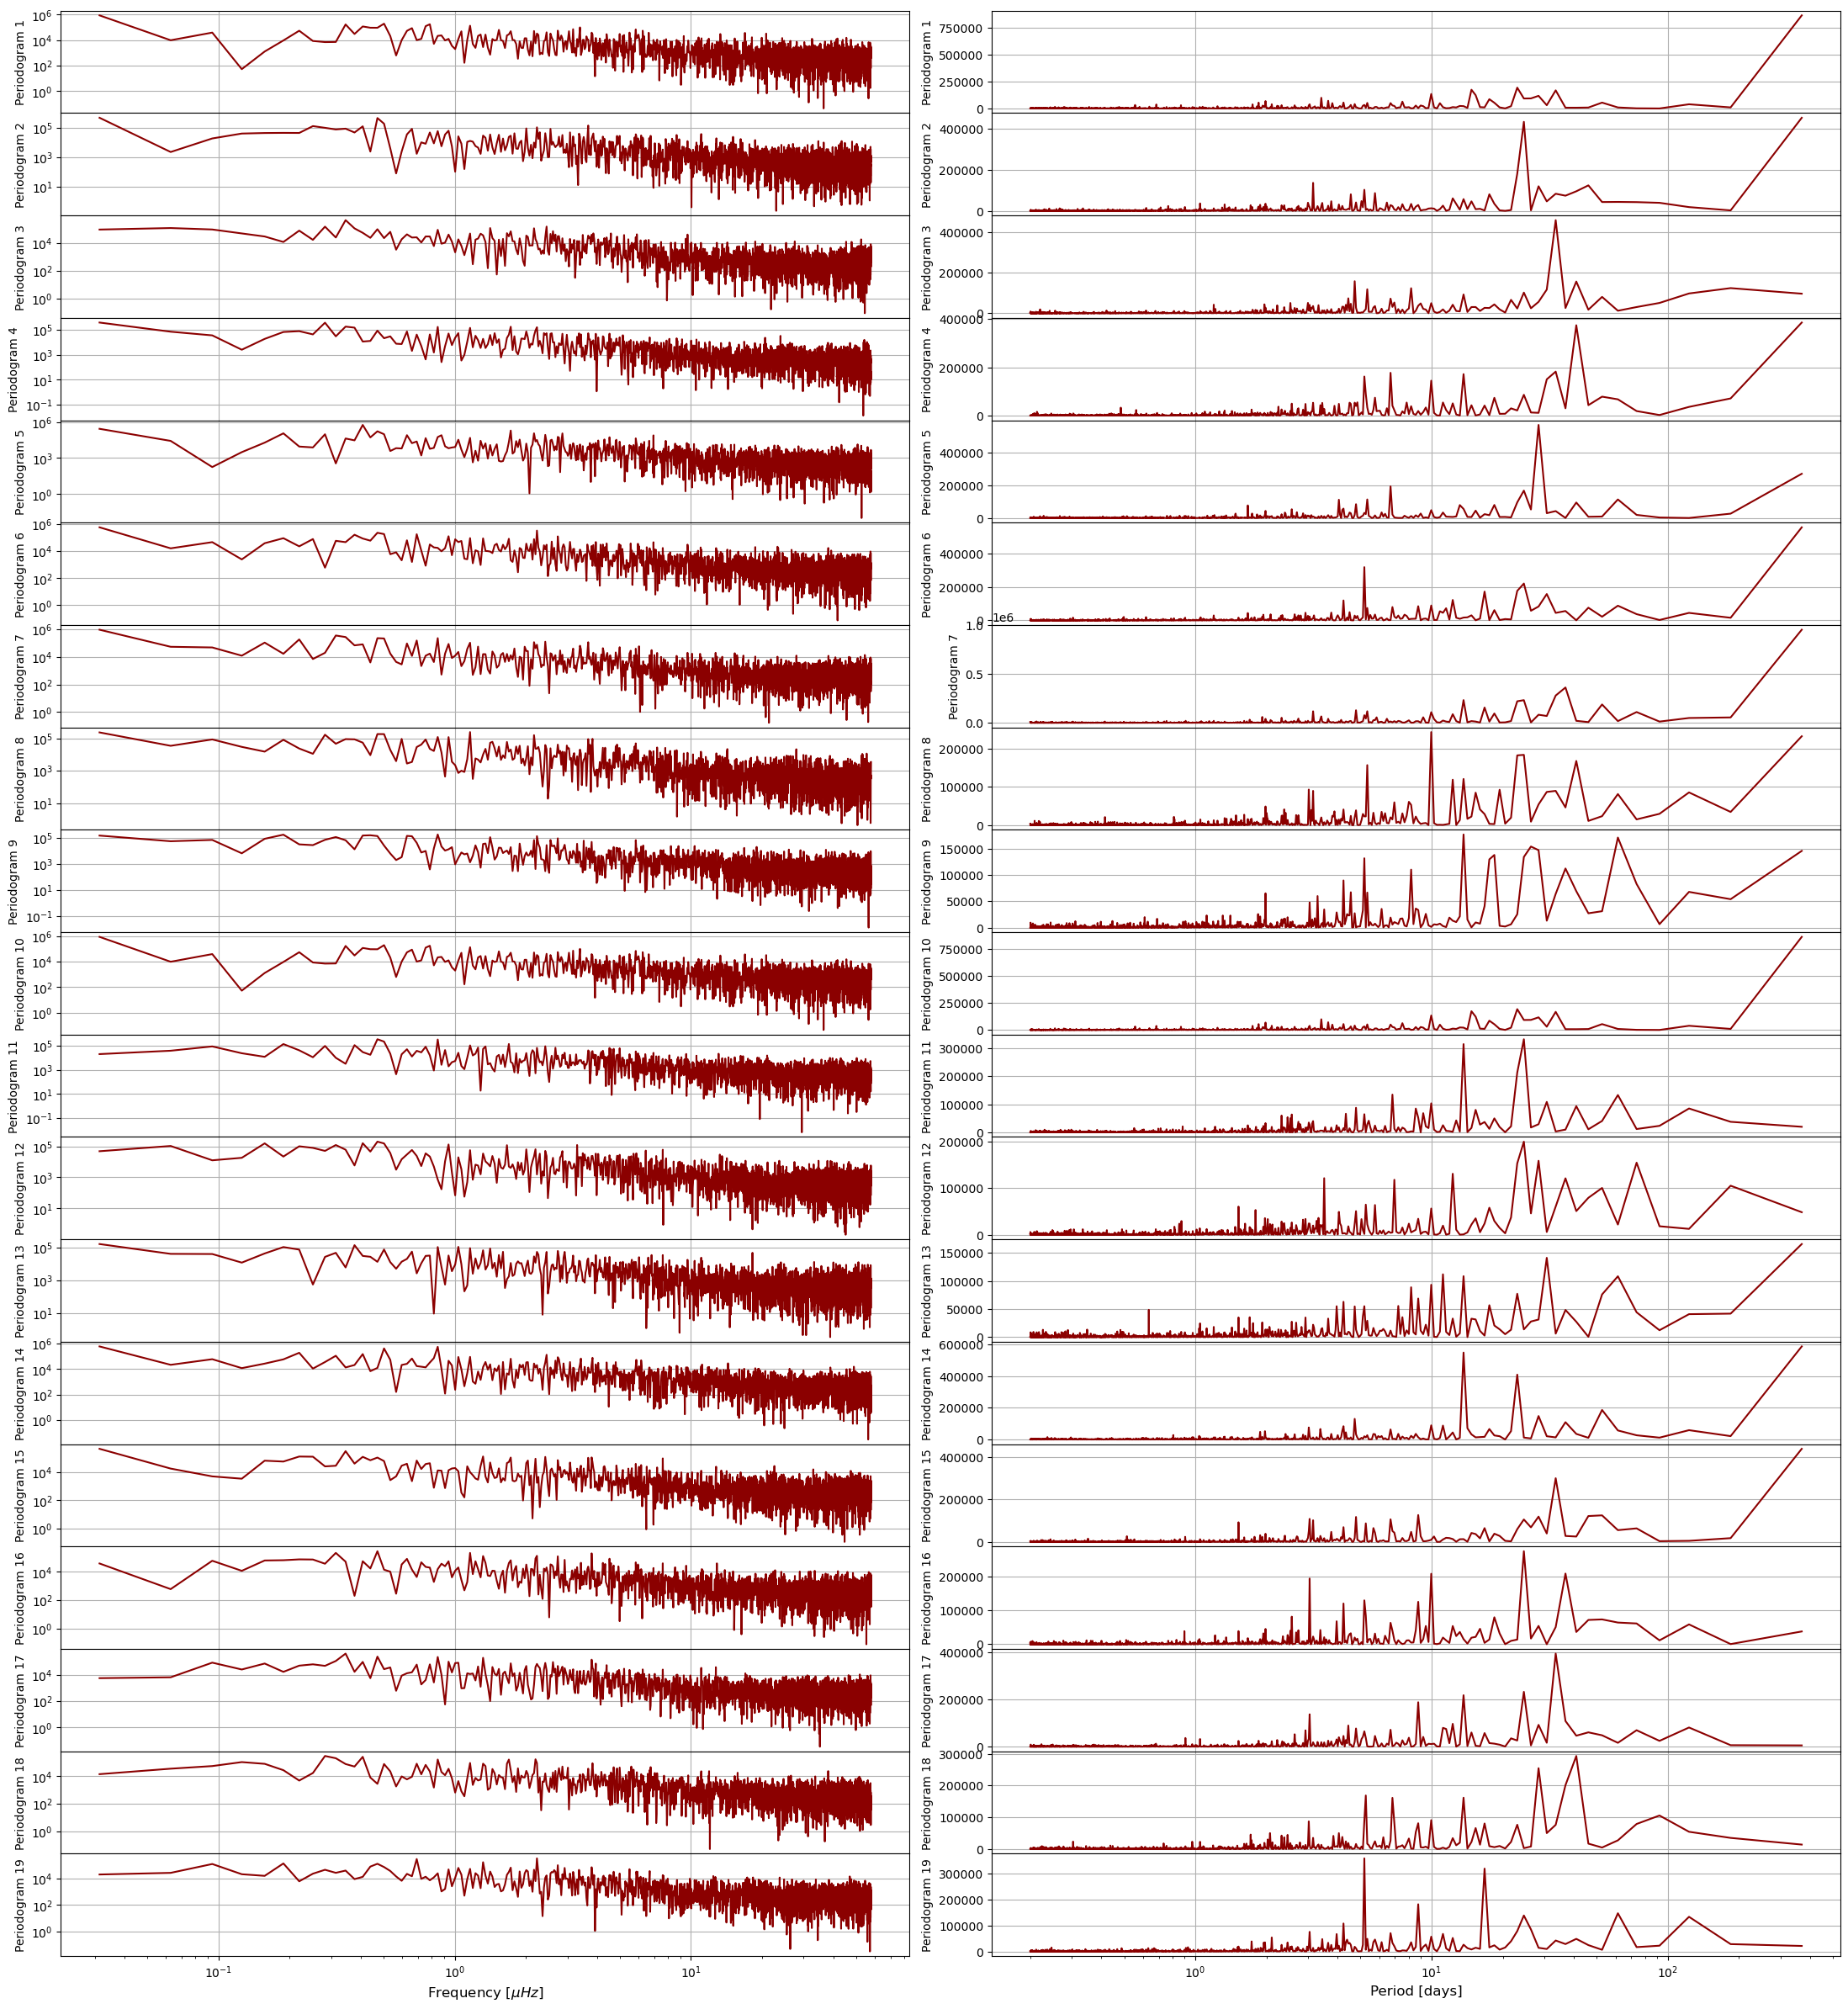

In [64]:
# plot RV periodograms
fig, axs = plt.subplots(19, 2, figsize=(22, 24), sharex='col')

for i in range(N_files):
    # Frequency periodogram
    axs[i][0].plot(freq_hz[mask] * 10**6, power_specs[i][mask], color='darkred')
    axs[i][0].set_yscale('log')
    axs[i][0].set_xscale('log')
    axs[i][0].set_ylabel(f'Periodogram {i+1}', size=10)
    axs[i][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
    axs[i][0].grid()

    # Periodogram
    axs[i][1].plot(1 / freq_days[mask], power_specs[i][mask], color='darkred')
    axs[i][1].set_xscale('log')
    axs[i][1].set_xlabel('Period [days]', size=12)
    axs[i][1].set_ylabel(f'Periodogram {i+1}', size=10)
    axs[i][1].grid()

fig.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

In [32]:
# split time series into chunks
n_chunks = 19
time_chunks = np.array_split(times, n_chunks)
ccf_chunks  = np.array_split(rv_ccf, n_chunks)
ccfE_chunks  = np.array_split(rv_ccfE, n_chunks)
tm_chunks   = np.array_split(rv_tm, n_chunks)
norm_mean = dt / len(time_chunks[0])  # normalization factor for the mean periodogram: timestep / number of points  # https://fr.mathworks.com/matlabcentral/answers/706048-normalization-of-power-spectral-density

# do FT for each chunk
periodograms = {}
for i in range(n_chunks):  # iterate over chunk index
    # power spectrum
    sp_ccf_i = np.fft.fft(ccf_chunks[i])  # apply FFT to the chunk i
    power_ccf_i = np.abs(sp_ccf_i)**2 * norm_mean  # calculate power

    sp_ccfE_i = np.fft.fft(ccfE_chunks[i])  # apply FFT to the chunk i
    power_ccfE_i = np.abs(sp_ccfE_i)**2 * norm_mean  # calculate power

    sp_tm_i = np.fft.fft(tm_chunks[i])
    power_tm_i = np.abs(sp_tm_i)**2 * norm_mean

    # calculate frequencies
    freq_i = np.fft.fftfreq(len(ccf_chunks[i]), dt)  # dt stays the same, so the frequencies are the same for all periodograms
    mask_i = freq_i > 0  # same mask for all periodograms

    periodograms[i] = [sp_ccf_i, power_ccf_i, sp_ccfE_i, power_ccfE_i, sp_tm_i, power_tm_i, freq_i, mask_i]  # save periodogram elements

In [33]:
# mean power spectrum
mean_power_ccf = np.mean([periodograms[i][1] for i in range(n_chunks)], axis=0)  # from CCF (N)
mean_power_ccfE = np.mean([periodograms[i][3] for i in range(n_chunks)], axis=0)  # from CCF (E)
mean_power_tm = np.mean([periodograms[i][5] for i in range(n_chunks)], axis=0)  # from TM

# save important information
m       = periodograms[0][-1]  # mask (same for all)
f_days  = periodograms[0][-2][m] # frequency in days^-1 (same for all)
f_hz    = f_days / 86400 # frequency in Hz (same for all)
df      = f_days[1] - f_days[0]
df_hz   = f_hz[1] - f_hz[0]
psd_ccf = mean_power_ccf[m]
psd_ccfE = mean_power_ccfE[m]
psd_tm  = mean_power_tm[m]

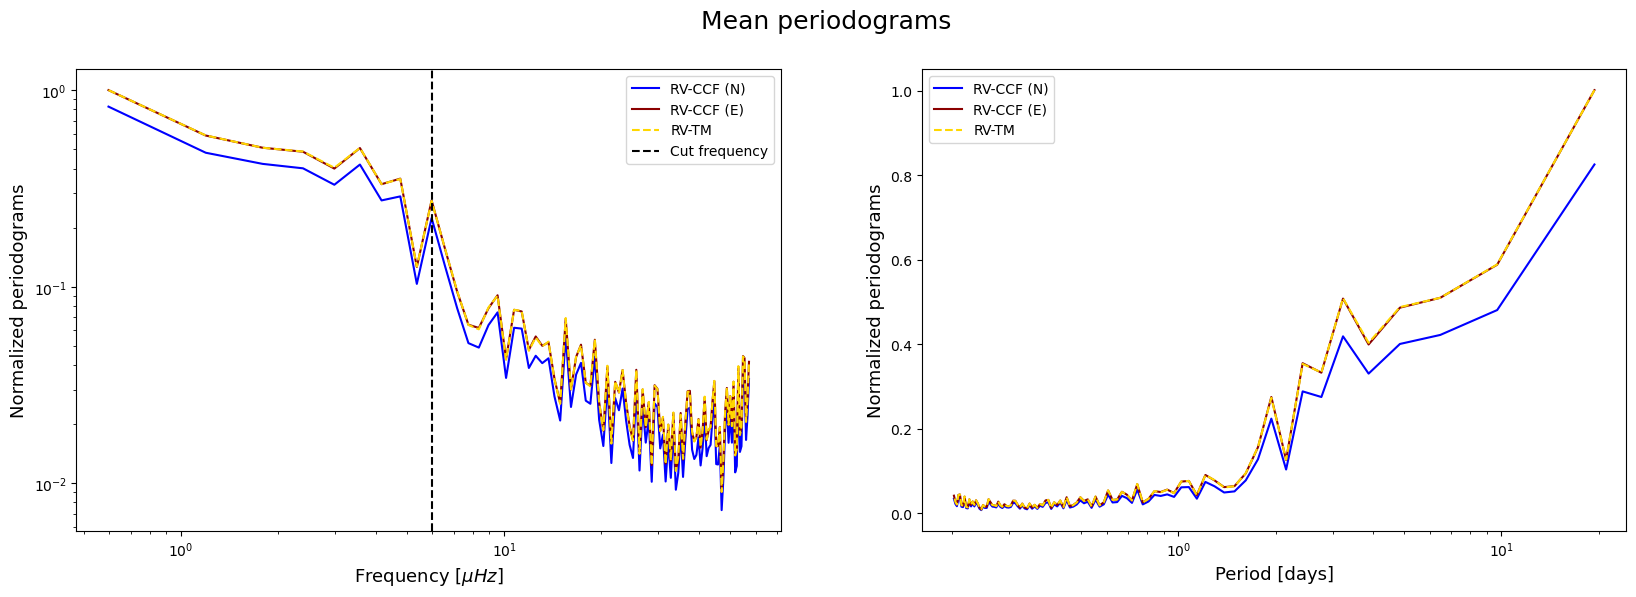

In [34]:
# put as a function of period too
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Mean periodograms', size=18)

axs[0].plot(f_hz * 10**6, psd_ccf, label='RV-CCF (N)', color='blue')
axs[0].plot(f_hz * 10**6, psd_ccfE, label='RV-CCF (E)', color='darkred')
axs[0].plot(f_hz * 10**6, psd_tm, label='RV-TM', color='gold', linestyle='--')
axs[0].axvline(6, color='k', linestyle='--', label='Cut frequency')
axs[0].set_xlabel(r'Frequency [$\mu Hz$]', size=13)
axs[0].set_ylabel('Normalized periodograms', size=13)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend()

axs[1].plot(1 / f_days, psd_ccf, label='RV-CCF (N)', color='blue')
axs[1].plot(1 / f_days, psd_ccfE, label='RV-CCF (E)', color='darkred')
axs[1].plot(1 / f_days, psd_tm, label='RV-TM', color='gold', linestyle='--')
#axs[1].axvline(4.8, color='k', linestyle='--', label='Cut frequency')
axs[1].set_xlabel('Period [days]', size=13)
axs[1].set_ylabel('Normalized periodograms', size=13)
axs[1].set_xscale('log')
#axs[1].set_yscale('log')
axs[1].legend()

plt.show()

In [35]:
# fit Harvey function
# initial guess
p0 = [
    sum(psd_ccf) * df_hz,                 # a -> total power
    4.8 / 10**6,                          # b -> turnover frequency from the plot above (where the power starts to decay)
    2.0,                                  # c -> classical value
    np.median(psd_ccf[f_hz * 10**6 > 20]) # d -> median of the noisy part from the plot above
]

# fit
params, _ = curve_fit(t.harvey, f_hz[1:], psd_ccf[1:], p0=p0)
a, b, c, d = params

In [36]:
# print results
print('Harvey fit to CCF periodogram:')
print(f'a={a:.2e} | b = {b:.2e} Hz | c = {round(c, 2)} | d = {round(d, 2)}')

Harvey fit to CCF periodogram:
a=2.37e-06 | b = 4.84e-06 Hz | c = 3.62 | d = 0.02


In [37]:
# calculate model from the parameters and SNR
model = t.harvey(f_hz, a, b, c, d)
snr = mean_power_ccf[m] / model

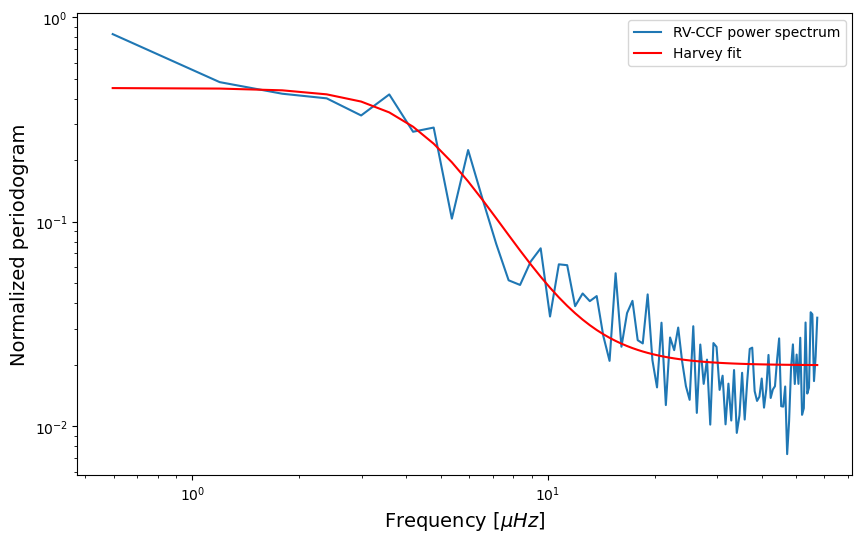

In [38]:
# plot fit
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_hz * 10**6, mean_power_ccf[m], label='RV-CCF power spectrum')
ax.loglog(f_hz * 10**6, model, label='Harvey fit', color='red')
#ax.axvline(fc / 86400 * 10**6)
ax.set_xlabel(r'Frequency [$\mu Hz$]', size=14)
ax.set_ylabel('Normalized periodogram', size=14)
ax.legend()
plt.show()

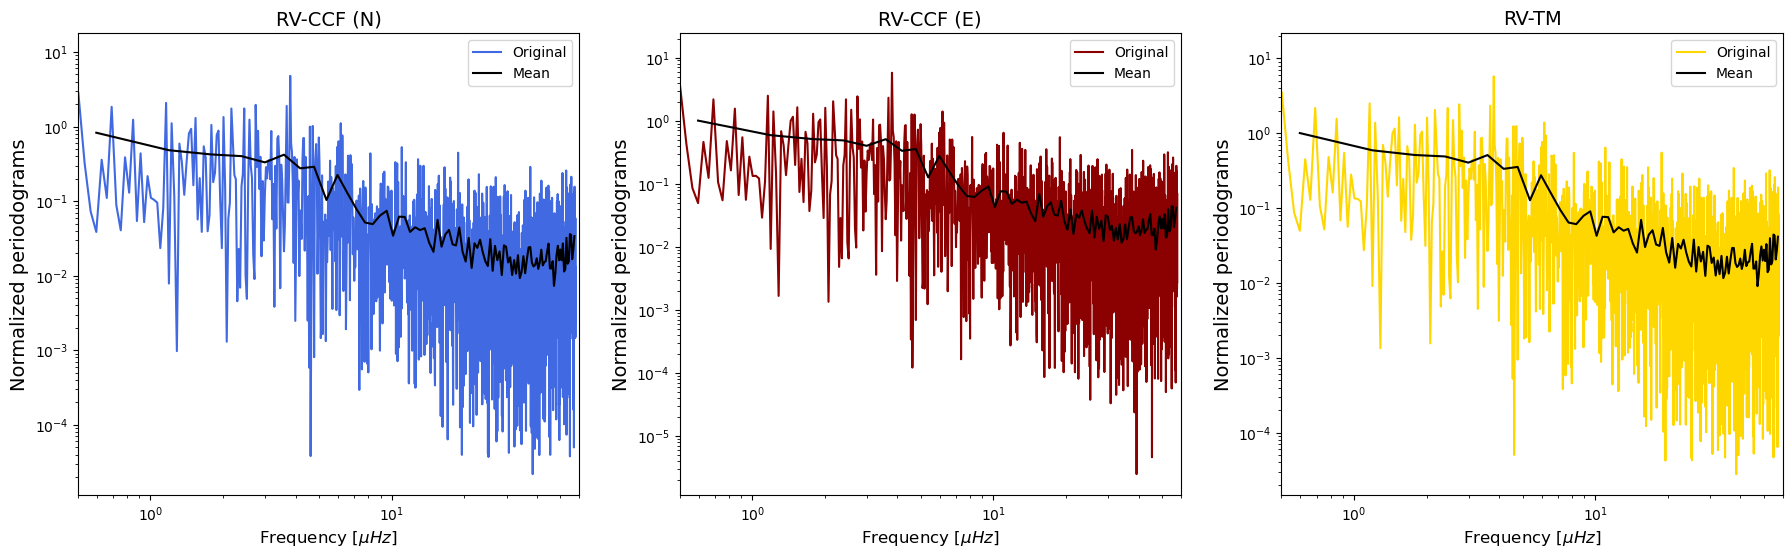

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(22, 6))

norm = dt / len(times)  # same timestape for all techniques, so same normalization

# RV-CCF (N)
axs[0].plot(freq_hz[mask] * 10**6, power_ccf[mask] * norm, color='royalblue', label='Original')  # original periodogram
axs[0].plot(f_hz * 10**6, mean_power_ccf[m], color='k', label='Mean')  # mean periodogram
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_title('RV-CCF (N)', size=14)
axs[0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[0].set_ylabel('Normalized periodograms', size=14)
axs[0].set_xlim(.5, 60)
axs[0].legend()

# RV-CCF (E)
axs[1].plot(freq_hz[mask] * 10**6, power_ccfE[mask] * norm, color='darkred', label='Original')  # original periodogram
axs[1].plot(f_hz * 10**6, mean_power_ccfE[m], color='k', label='Mean')  # mean periodogram
axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_title('RV-CCF (E)', size=14)
axs[1].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[1].set_ylabel('Normalized periodograms', size=14)
axs[1].set_xlim(.5, 60)
axs[1].legend()

# RV-TM
axs[2].plot(freq_hz[mask] * 10**6, power_tm[mask] * norm, color='gold', label='Original')  # original periodogram
axs[2].plot(f_hz * 10**6, mean_power_tm[m], color='k', label='Mean')  # mean periodogram
axs[2].set_yscale('log')
axs[2].set_xscale('log')
axs[2].set_title('RV-TM', size=14)
axs[2].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[2].set_ylabel('Normalized periodograms', size=14)
axs[2].set_xlim(.5, 60)
axs[2].legend()

plt.show()

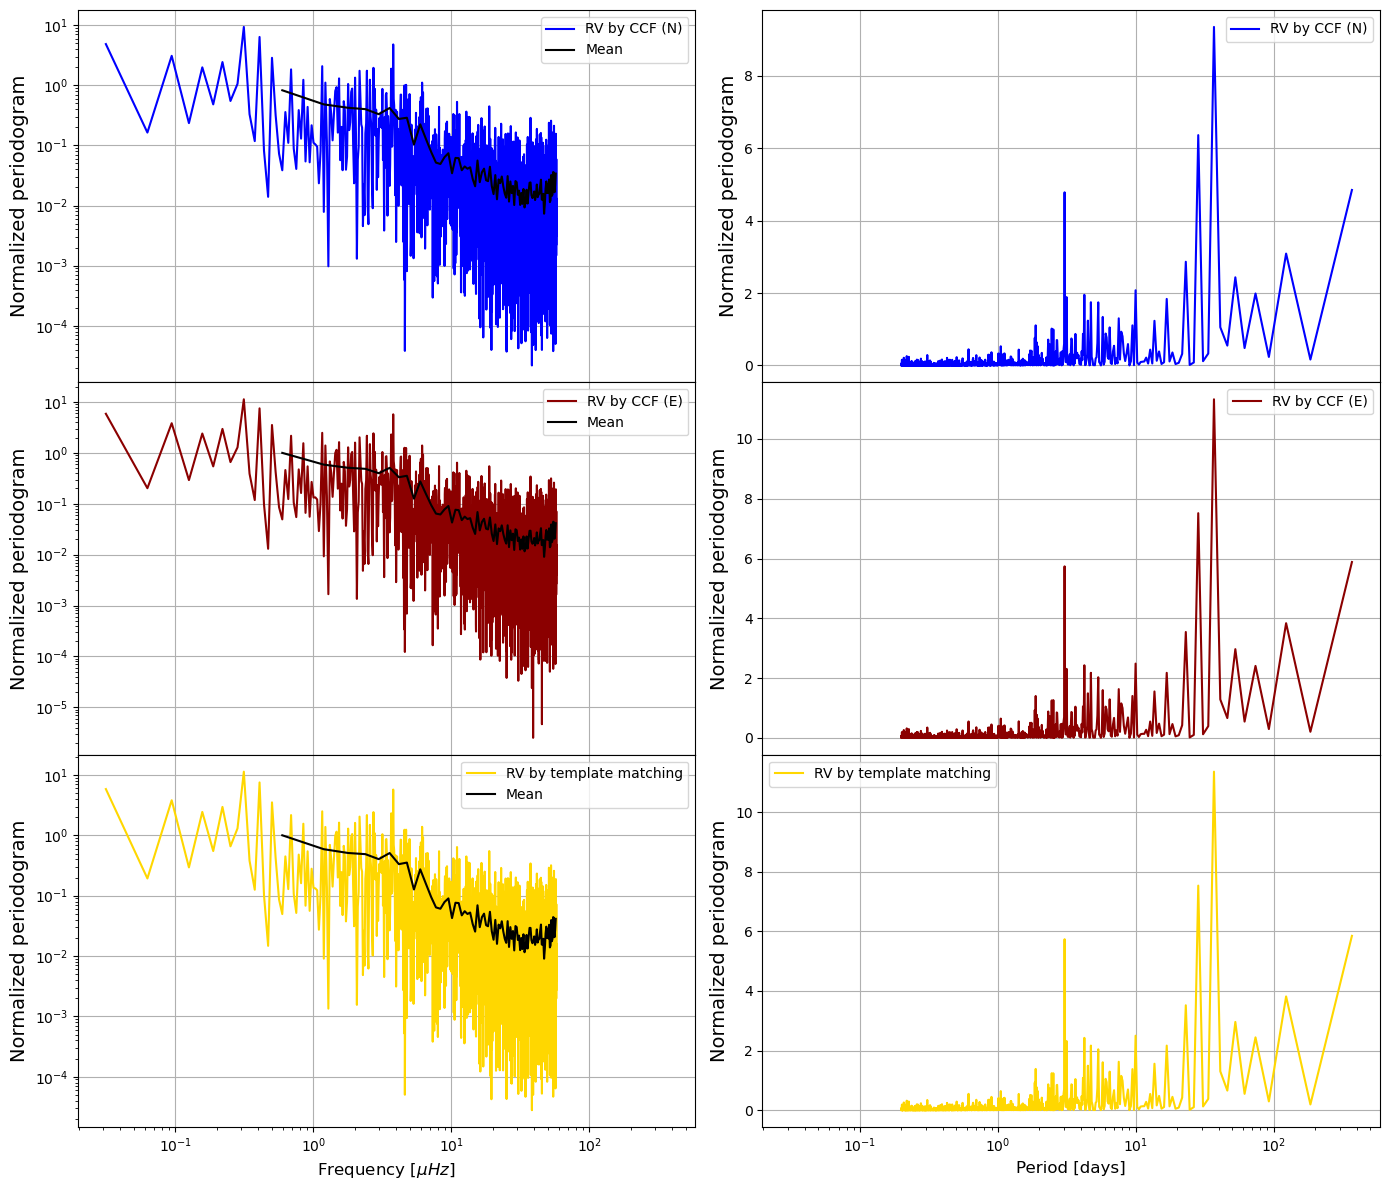

In [40]:
# plot RV periodograms
fig, axs = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

# CCF (N)
# Frequency periodogram
axs[0][0].plot(freq_hz[mask] * 10**6, power_ccf[mask] * norm, color='blue', label='RV by CCF (N)')
axs[0][0].plot(f_hz * 10**6, mean_power_ccf[m], color='k', label='Mean')  # mean periodogram
axs[0][0].set_yscale('log')
axs[0][0].set_xscale('log')
axs[0][0].set_ylabel('Normalized periodogram', size=14)
axs[0][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[0][0].legend()
axs[0][0].grid()

# Periodogram
axs[0][1].plot(1 / freq_days[mask], power_ccf[mask] * norm, color='blue', label='RV by CCF (N)')
axs[0][1].set_xscale('log')
axs[0][1].set_xlabel('Period [days]', size=12)
axs[0][1].set_ylabel('Normalized periodogram', size=14)
axs[0][1].legend()
axs[0][1].grid()

# CCF (E)
# Frequency periodogram
axs[1][0].plot(freq_hz[mask] * 10**6, power_ccfE[mask] * norm, color='darkred', label='RV by CCF (E)')
axs[1][0].plot(f_hz * 10**6, mean_power_ccfE[m], color='k', label='Mean')  # mean periodogram
axs[1][0].set_yscale('log')
axs[1][0].set_xscale('log')
axs[1][0].set_ylabel('Normalized periodogram', size=14)
axs[1][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[1][0].legend()
axs[1][0].grid()

# Periodogram
axs[1][1].plot(1 / freq_days[mask], power_ccfE[mask] * norm, color='darkred', label='RV by CCF (E)')
axs[1][1].set_xscale('log')
axs[1][1].set_xlabel('Period [days]', size=12)
axs[1][1].set_ylabel('Normalized periodogram', size=14)
axs[1][1].legend()
axs[1][1].grid()

# TM
# Frequency periodogram
axs[2][0].plot(freq_hz[mask] * 10**6, power_tm[mask] * norm, color='gold', label='RV by template matching')
axs[2][0].plot(f_hz * 10**6, mean_power_tm[m], color='k', label='Mean')  # mean periodogram
axs[2][0].set_yscale('log')
axs[2][0].set_xscale('log')
axs[2][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[2][0].set_ylabel('Normalized periodogram', size=14)
axs[2][0].legend()
axs[2][0].grid()

# Periodogram
axs[2][1].plot(1 / freq_days[mask], power_tm[mask] * norm, color='gold', label='RV by template matching')
axs[2][1].set_xscale('log')
#axs[2][1].set_yscale('log')
axs[2][1].set_xlabel('Period [days]', size=12)
axs[2][1].set_ylabel('Normalized periodogram', size=14)
axs[2][1].legend()
axs[2][1].grid()

fig.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

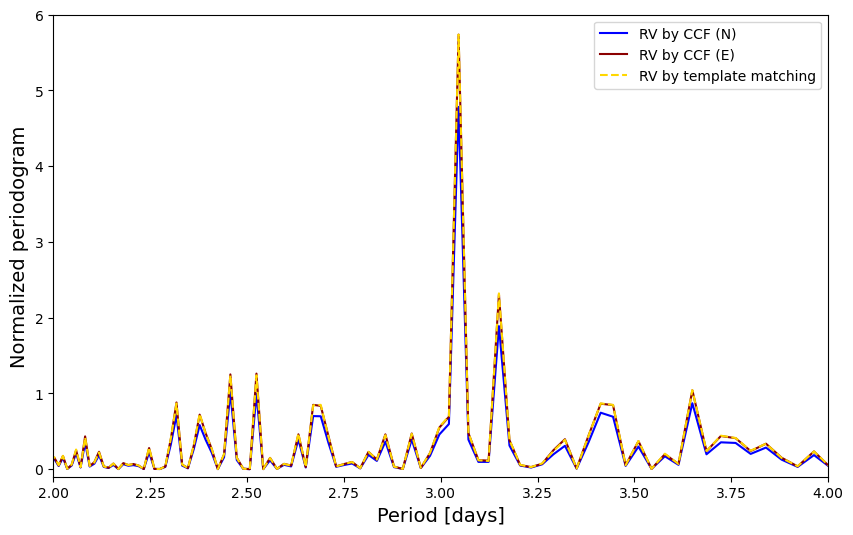

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(1 / freq_days[mask], power_ccf[mask] * norm, color='blue', label='RV by CCF (N)')
ax.plot(1 / freq_days[mask], power_ccfE[mask] * norm, color='darkred', label='RV by CCF (E)')
ax.plot(1 / freq_days[mask], power_tm[mask] * norm, color='gold', label='RV by template matching', linestyle='--')
ax.set_xlabel('Period [days]', size=14)
ax.set_ylabel('Normalized periodogram', size=14)
#ax.set_xscale('log')
ax.set_xlim(2, 4)
ax.set_ylim(-.1, 6)
ax.legend()

plt.show()

## Apply PCA

In [42]:
# corrected wavelength
lambda_corr = t.calculate_lambda_corr(wl, rv_ccf)

In [43]:
lambda_corr

array([[6173.10077184, 6173.10489084, 6173.10900884, ..., 6173.59086384,
        6173.59498184, 6173.59909984],
       [6173.10076235, 6173.10488135, 6173.10899935, ..., 6173.59085435,
        6173.59497235, 6173.59909035],
       [6173.10077156, 6173.10489056, 6173.10900856, ..., 6173.59086356,
        6173.59498156, 6173.59909956],
       ...,
       [6173.10077063, 6173.10488963, 6173.10900763, ..., 6173.59086263,
        6173.59498063, 6173.59909863],
       [6173.10077774, 6173.10489674, 6173.10901474, ..., 6173.59086974,
        6173.59498774, 6173.59910574],
       [6173.10076185, 6173.10488085, 6173.10899885, ..., 6173.59085385,
        6173.59497185, 6173.59908985]], shape=(3686, 122))

In [44]:
# interpolation to a common reference grid, as lambda_corr is different for each spectrum

resampled_flux = []

for wave, flux in zip(lambda_corr, data_spectra):  # iterate over wavelength, spectrum pairs
    interp_flux = np.interp(wl, wave, flux)  # interpolate the observed spectrum into the reference grid
    resampled_flux.append(interp_flux)  # save

spectra_matrix = np.array(resampled_flux)

In [45]:
# apply double centering to the spectra matrix
spectra_centered = t.double_centering(spectra_matrix)

In [46]:
# apply PCA to the centered spectra matrix
n_components = 20
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 20 components: [5.84058761e-01 3.37753042e-01 7.44346744e-02 2.20807852e-03
 1.32671794e-03 1.44220570e-04 4.44046650e-05 1.26668343e-05
 8.10830686e-06 4.93663843e-06 1.60434188e-06 1.25245686e-06
 3.95939414e-07 1.24909119e-07 9.19352324e-08 7.64845279e-08
 1.59823771e-08 1.23543483e-08 1.14953082e-08 1.12403799e-08]


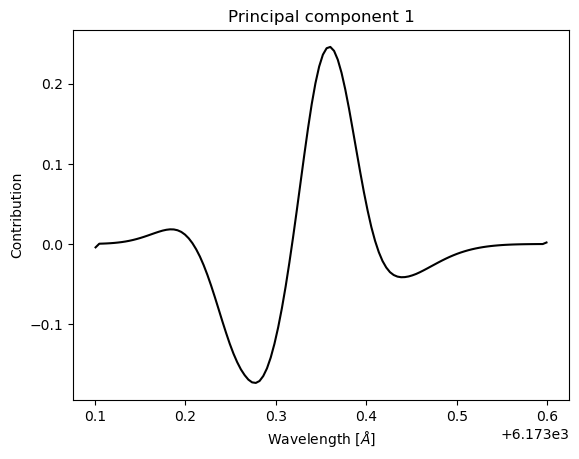

In [47]:
# plot loadings
# plot shows how much each wavelength value (feature) contributes to the variance of a PC
for i in range(1):  # put n_components instead of 1 to see all the plots
    plt.plot(wl, pca_flux.components_[i], color='k')
    plt.title(f'Principal component {i + 1}', size=12)
    plt.xlabel(r'Wavelength [$\AA$]')
    plt.ylabel('Contribution')
    plt.show()

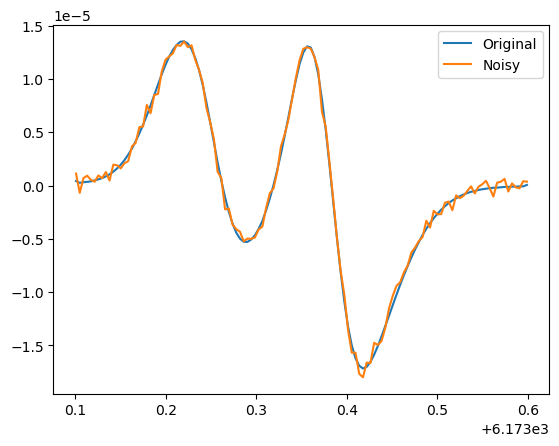

In [48]:
spectra_noisy = spectra_centered + np.random.normal(0, .0000005, len(wl))  # add gaussian noise to the original data
plt.plot(wl, spectra_centered[0], label='Original')
plt.plot(wl, spectra_noisy[0], label='Noisy')
plt.legend()
plt.show()

In [49]:
# component significance
# multiple realizations allow to calculate error bars
n_realizations = 20
sigma = .0000005
mean_maxes = t.calculate_pca_significance(n_realizations, n_components, spectra_centered, sigma)  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

100%|██████████| 20/20 [00:00<00:00, 37.04it/s]


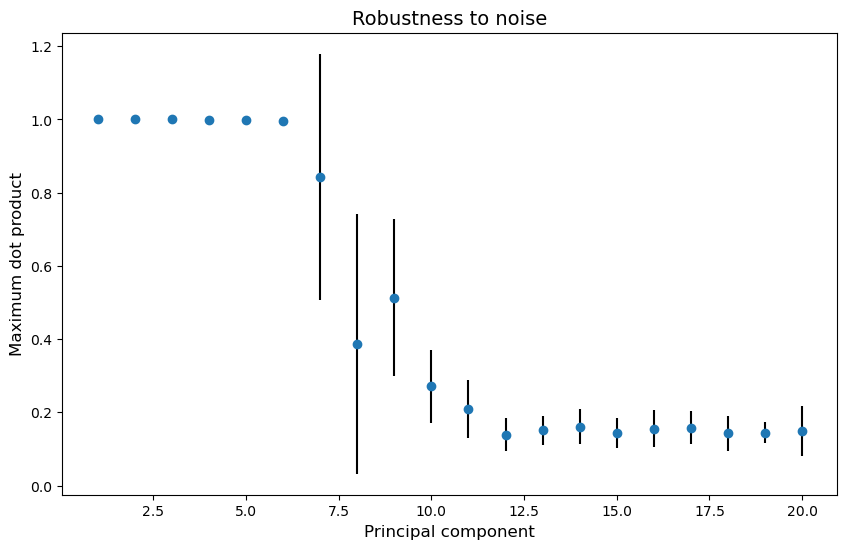

In [50]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[:, 0], mean_maxes[:, 1], fmt='o', ecolor='k')
ax.set_title('Robustness to noise', size=14)
ax.set_xlabel('Principal component', size=12)
ax.set_ylabel('Maximum dot product', size=12)
plt.show()

In [51]:
dt = times[1] - times[0]

# power spectrum
sp = np.array([np.fft.fft(pcs[:, i]) for i in range(n_components)])
power = np.abs(sp)**2

# calculate frequencies
# using fftfreq
freq = np.array([np.fft.fftfreq(pcs[:, i].shape[0], dt) for i in range(n_components)])

# by hand
N = len(times)
df = 1 / (N * dt)
freq2 = np.array([
    k * df if k < N//2 else (k - N) * df  # second half of the list goes negative
    for k in range(N)
])

In [52]:
N2 = 20
print([k if k < N2//2 else (k - N2) for k in range(N2)])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1]


In [53]:
min(freq[0]), max(freq[0])

(np.float64(-5.000000000000001), np.float64(4.9972870320130225))

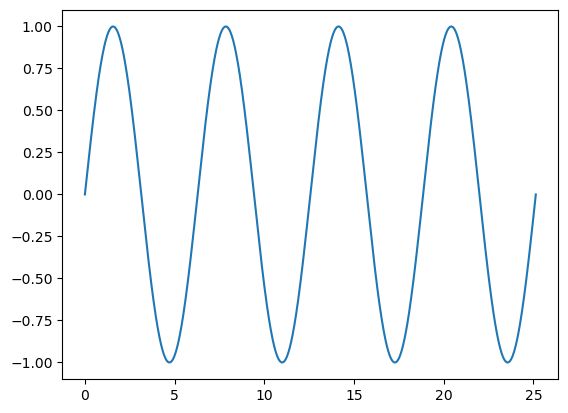

In [54]:
# check if FFT is working well
# define a function with a known frequency
theta = np.linspace(0, 8 * np.pi, 1000)
sin = np.sin(theta)
plt.plot(theta, sin)
plt.show()

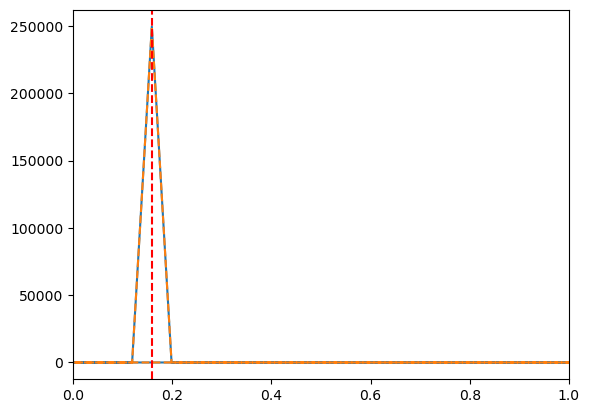

In [55]:
# check if FFT is working well
fft_sin = np.fft.fft(sin)
step = theta[1] - theta[0]
f_sin = np.fft.fftfreq(fft_sin.shape[0], step)
df_sin = 1 / (fft_sin.shape[0] * step)
f2 = np.arange(0, 1/step, df_sin)
f3 = np.array([
    k * df_sin if k < fft_sin.shape[0]//2 else (k - fft_sin.shape[0]) * df_sin  # second half of the list goes negative
    for k in range(fft_sin.shape[0])
])
plt.plot(f_sin, np.abs(fft_sin)**2)
plt.plot(f3, np.abs(fft_sin)**2, linestyle='--')
plt.axvline(1 / (2 * np.pi), color='red', linestyle='--')
plt.xlim(0, 1)
plt.show()

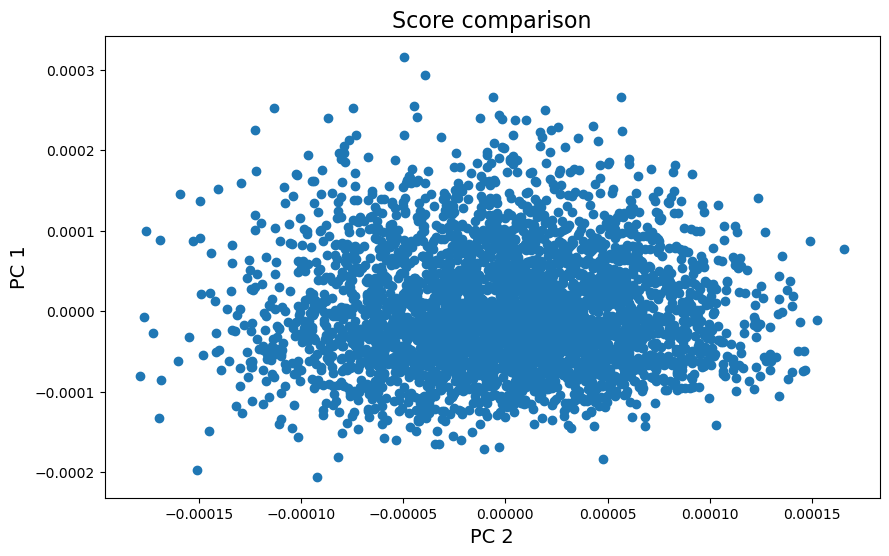

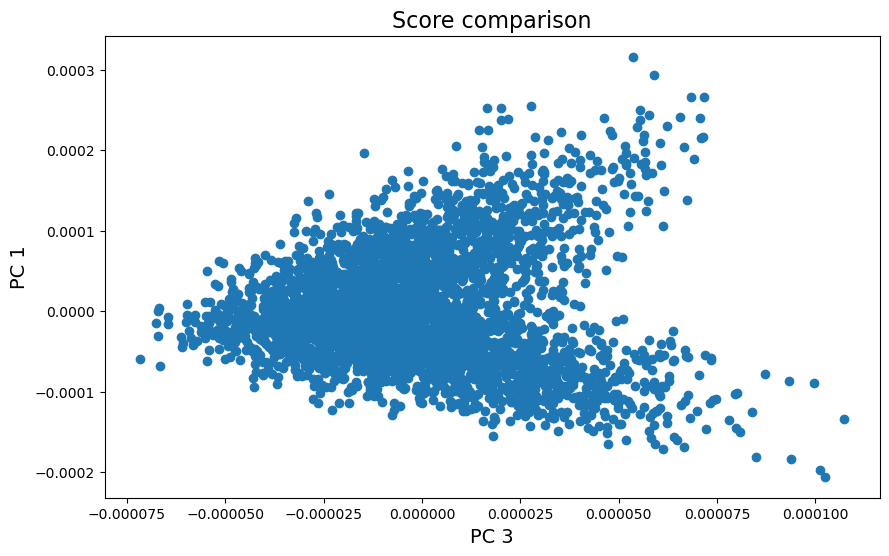

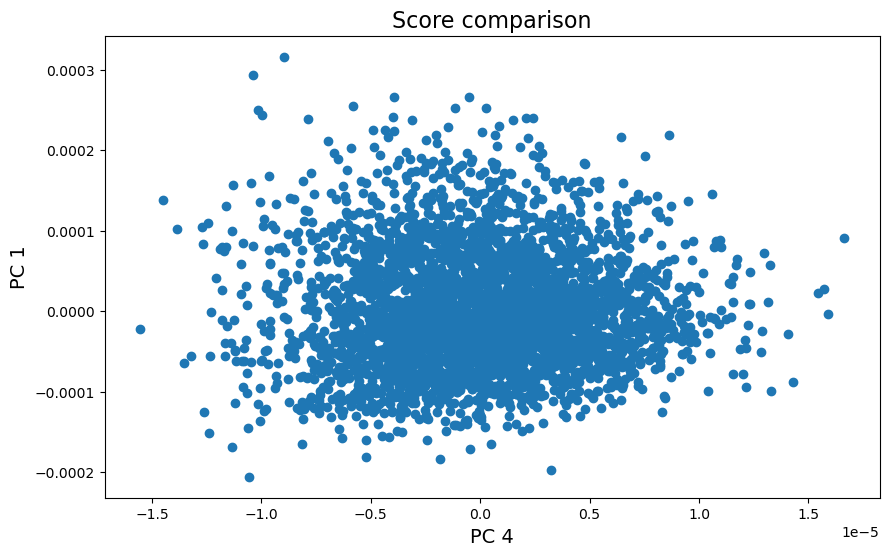

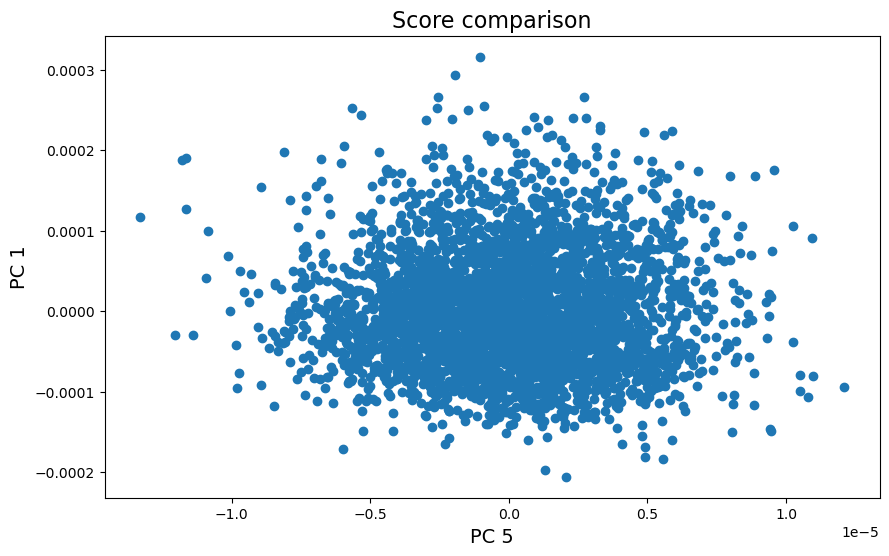

In [65]:
for i in range(1, 5):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.scatter(pcs[:, i], pcs[:, 0])
    ax.set_xlabel(f'PC {i + 1}', size=14)
    ax.set_ylabel('PC 1', size=14)
    ax.set_title('Score comparison', size=16)

    plt.show()

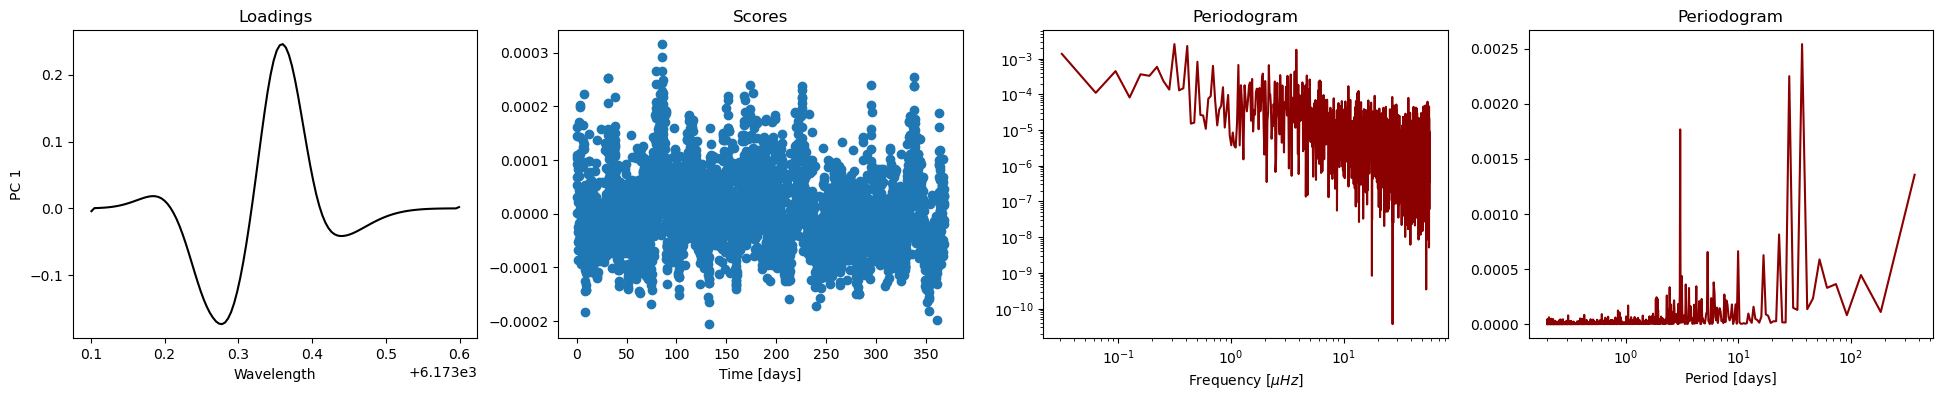

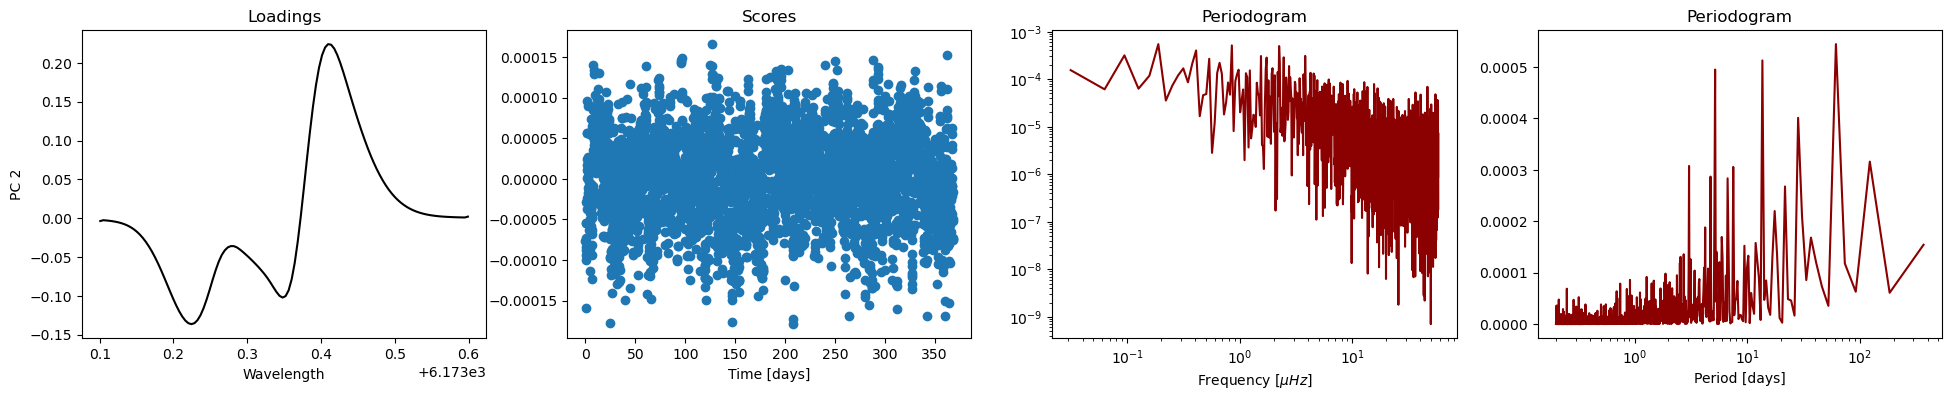

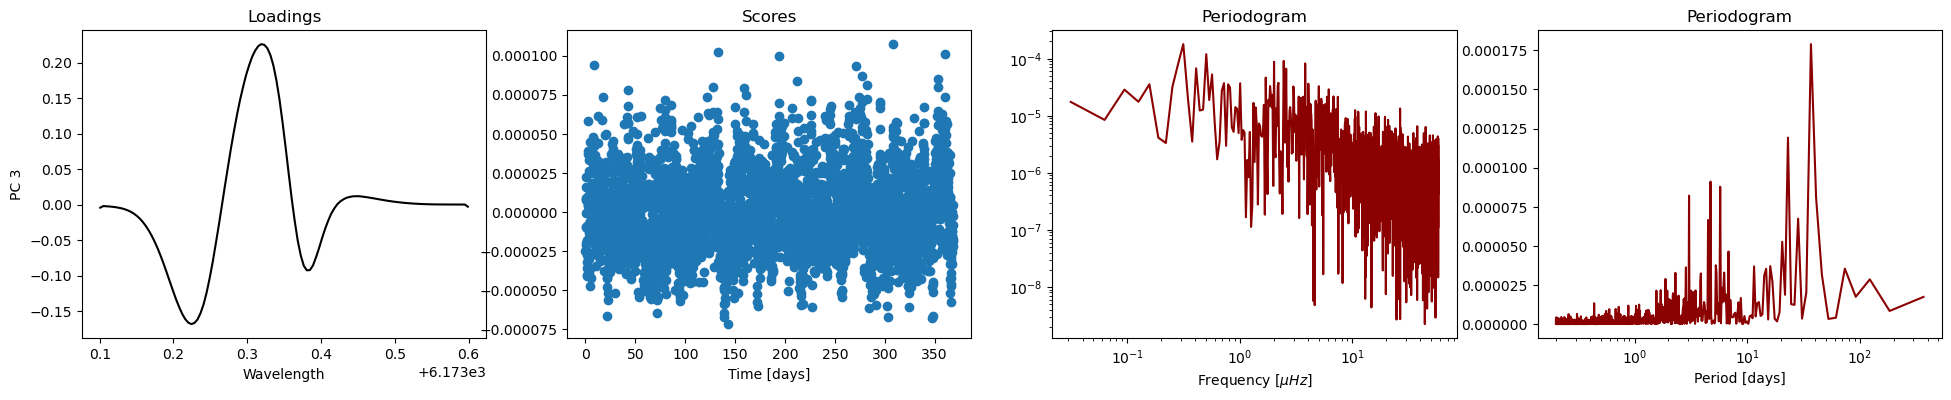

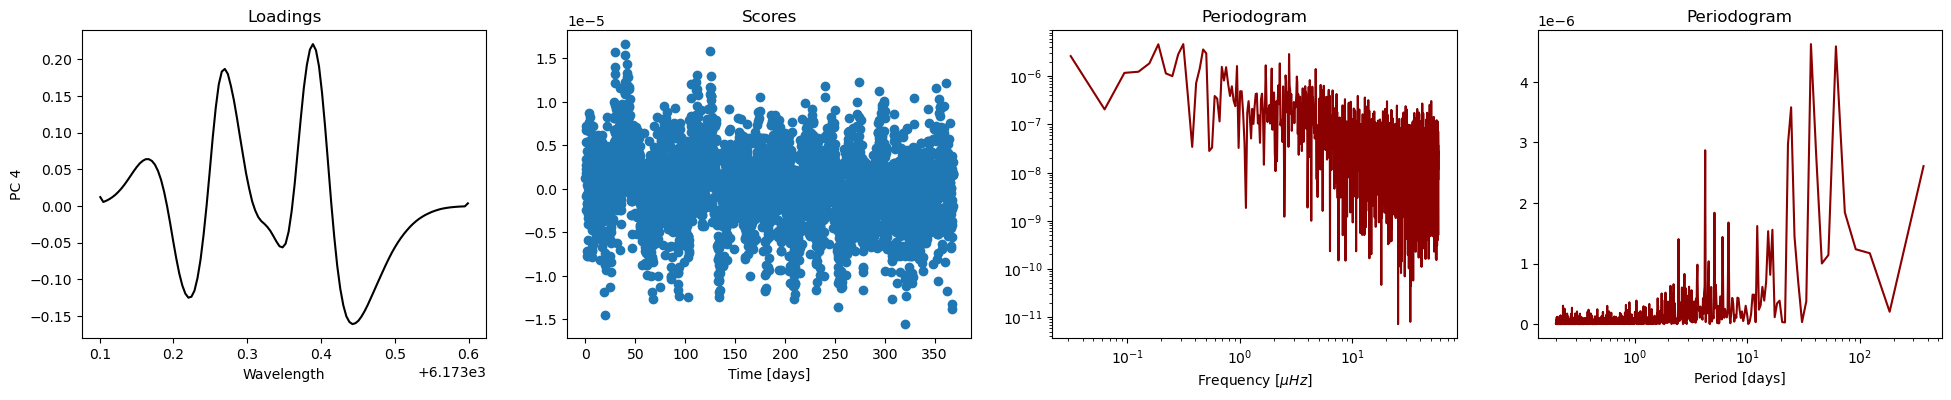

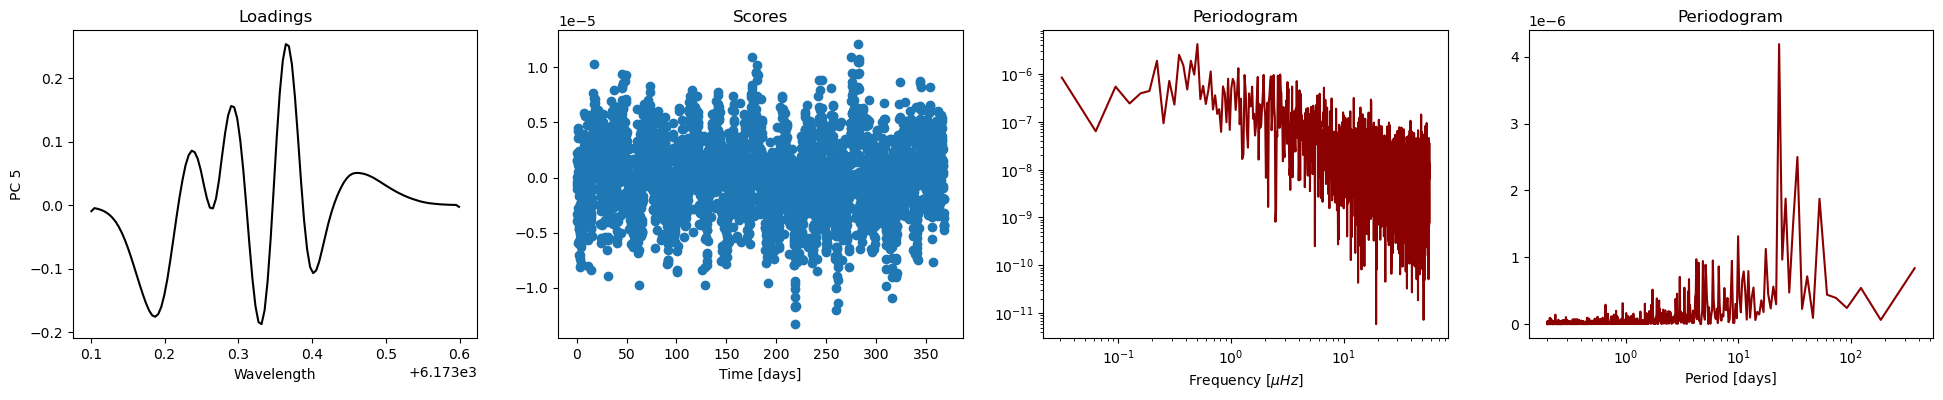

In [56]:
# plot
for i in range(5):
    fig, axs = plt.subplots(1, 4, figsize=(24, 4))
    
    # Loadings
    axs[0].plot(wl, pca_flux.components_[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, pcs[:, i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time [days]')

    # Fourier power spectrum (frequency)
    mask = freq[i] > 0
    axs[2].plot(freq[i][mask] / 86400 * 10**6, power[i][mask], color='darkred')  # frequency divided by 86400 to pass from days^-1 to Hz, then multiplied by 10^6 to pass to microhertz
    axs[2].set_yscale('log')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram', size=12)
    axs[2].set_xlabel(r'Frequency [$\mu Hz$]')
    
    # Fourier periodogram (period)
    axs[3].plot(1 / freq[i][mask], power[i][mask], color='darkred')
    #axs[3].set_yscale('log')
    axs[3].set_xscale('log')
    axs[3].set_title('Periodogram', size=12)
    axs[3].set_xlabel('Period [days]')

    plt.show()